In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

In [29]:
# Load your data
data = pd.read_csv('QGIS_df.csv')

In [30]:
house_df = data[data['Category'] == 'house']
condo_df = data[data['Category'] == 'condo']
apt_df = data[data['Category'] == 'apartment']
com_df = data[data['Category'] == 'commercial']
land_df = data[data['Category'] == 'land']
RR_df = pd.concat([house_df, condo_df, apt_df], ignore_index=True)
CR_df = pd.concat([com_df, land_df], ignore_index=True)

In [33]:
# Cross-validation setup
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [35]:
def objective(trial):
    # Hyperparameter ranges as specified
    params = {
        'n_estimators': trial.suggest_categorical('n_estimators', [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]),
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'max_features': trial.suggest_int('max_features', 2, 9),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10)
    }
    
    # Create Extra Trees Regressor with current hyperparameters
    et_regressor = ExtraTreesRegressor(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        max_features=params['max_features'],
        min_samples_leaf=params['min_samples_leaf'],
        min_samples_split=params['min_samples_split'],
        criterion='squared_error',
        bootstrap=False
    )
    
    # Perform cross-validation
    scores = cross_val_score(et_regressor, X, y, cv=5, scoring='r2')
    #scores = cross_val_score(et_regressor, X, y, cv=kfold, scoring='r2')
    return np.mean(scores)

In [37]:
def optimize_extra_trees(X, y):
    # Create a study object and optimize the objective function
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=100)
    
    # Print best parameters and score
    print("Best trial:")
    trial = study.best_trial
    print(f"  Value: {trial.value}")
    print("  Params: ")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
    
    return study.best_params

In [43]:
# Train Extra Trees with Best Params and Get Feature Importances
def get_feature_importance(X, y, best_params):
    model = ExtraTreesRegressor(**best_params, random_state=42)
    model.fit(X, y)
    
    # Extract feature importances
    feature_importances = model.feature_importances_
    
    # Convert to DataFrame
    importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)
    
    # Print Top Features
    print("\nTop Features:")
    print(importance_df)
    
    # Plot Feature Importances
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='royalblue')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title('Feature Importance in Extra Trees')
    plt.gca().invert_yaxis()  # Highest importance at the top
    plt.show()
    
    return importance_df

### ET with House Data (Count)

In [47]:
# Assuming df is already loaded and preprocessed
y = house_df['Price']
X = house_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusCount', 'SchoolCount', 'MallCount', 'HospitalCount']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)

[I 2025-02-02 18:45:30,311] A new study created in memory with name: no-name-66e8499d-3feb-4465-b146-b696ab2caa24
[I 2025-02-02 18:45:35,926] Trial 0 finished with value: 0.08629531177289666 and parameters: {'n_estimators': 110, 'max_depth': 10, 'max_features': 7, 'min_samples_leaf': 4, 'min_samples_split': 3}. Best is trial 0 with value: 0.08629531177289666.
[I 2025-02-02 18:45:37,124] Trial 1 finished with value: -0.6112752602654857 and parameters: {'n_estimators': 20, 'max_depth': 12, 'max_features': 6, 'min_samples_leaf': 2, 'min_samples_split': 10}. Best is trial 0 with value: 0.08629531177289666.
[I 2025-02-02 18:45:38,255] Trial 2 finished with value: -2.5805862719215433 and parameters: {'n_estimators': 130, 'max_depth': 2, 'max_features': 3, 'min_samples_leaf': 5, 'min_samples_split': 9}. Best is trial 0 with value: 0.08629531177289666.
[I 2025-02-02 18:45:41,956] Trial 3 finished with value: -0.12007082932975517 and parameters: {'n_estimators': 40, 'max_depth': 18, 'max_featur

Best trial:
  Value: 0.12412672511285017
  Params: 
    n_estimators: 160
    max_depth: 10
    max_features: 8
    min_samples_leaf: 4
    min_samples_split: 6

Top Features:
         Feature  Importance
4      Land_Area    0.456368
6    SchoolCount    0.146863
0     LRTHubDist    0.113405
3     Floor_Area    0.109834
7      MallCount    0.081517
5       BusCount    0.037314
8  HospitalCount    0.025324
1   Num_Bedrooms    0.016917
2  Num_Bathrooms    0.012459


NameError: name 'plt' is not defined

### ET with Condo Data (Count)

In [51]:
# Assuming df is already loaded and preprocessed
y = condo_df['Price']
X = condo_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusCount', 'SchoolCount', 'MallCount', 'HospitalCount']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)

[I 2025-02-02 19:03:38,742] A new study created in memory with name: no-name-7e38c924-5b32-4490-8d7a-789f0db7c072
[I 2025-02-02 19:03:39,703] Trial 0 finished with value: -0.06993893357831234 and parameters: {'n_estimators': 90, 'max_depth': 2, 'max_features': 6, 'min_samples_leaf': 2, 'min_samples_split': 3}. Best is trial 0 with value: -0.06993893357831234.
[I 2025-02-02 19:03:41,914] Trial 1 finished with value: 0.2941757089495515 and parameters: {'n_estimators': 70, 'max_depth': 7, 'max_features': 8, 'min_samples_leaf': 2, 'min_samples_split': 3}. Best is trial 1 with value: 0.2941757089495515.
[I 2025-02-02 19:03:57,345] Trial 2 finished with value: 0.38904001079639244 and parameters: {'n_estimators': 200, 'max_depth': 13, 'max_features': 9, 'min_samples_leaf': 5, 'min_samples_split': 7}. Best is trial 2 with value: 0.38904001079639244.
[I 2025-02-02 19:04:00,249] Trial 3 finished with value: 0.12476429709416859 and parameters: {'n_estimators': 130, 'max_depth': 8, 'max_features':

Best trial:
  Value: 0.4107037209929295
  Params: 
    n_estimators: 150
    max_depth: 19
    max_features: 9
    min_samples_leaf: 2
    min_samples_split: 10

Top Features:
         Feature  Importance
3     Floor_Area    0.503102
1   Num_Bedrooms    0.153925
2  Num_Bathrooms    0.100514
6    SchoolCount    0.054710
7      MallCount    0.054282
0     LRTHubDist    0.046032
5       BusCount    0.043838
8  HospitalCount    0.043598
4      Land_Area    0.000000


AttributeError: module 'matplotlib' has no attribute 'figure'

[I 2025-02-02 19:25:42,529] A new study created in memory with name: no-name-f4ad47f6-eeca-426e-ab35-4ecdbe7eaa62
[I 2025-02-02 19:25:42,684] Trial 0 finished with value: 0.4462440135522381 and parameters: {'n_estimators': 30, 'max_depth': 6, 'max_features': 5, 'min_samples_leaf': 2, 'min_samples_split': 4}. Best is trial 0 with value: 0.4462440135522381.
[I 2025-02-02 19:25:42,750] Trial 1 finished with value: 0.3473157603276088 and parameters: {'n_estimators': 10, 'max_depth': 4, 'max_features': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}. Best is trial 0 with value: 0.4462440135522381.
[I 2025-02-02 19:25:43,414] Trial 2 finished with value: 0.35922441764644286 and parameters: {'n_estimators': 180, 'max_depth': 16, 'max_features': 8, 'min_samples_leaf': 9, 'min_samples_split': 7}. Best is trial 0 with value: 0.4462440135522381.
[I 2025-02-02 19:25:43,481] Trial 3 finished with value: 0.3457241566867617 and parameters: {'n_estimators': 10, 'max_depth': 5, 'max_features': 9, 'm

Best trial:
  Value: 0.4891382000410525
  Params: 
    n_estimators: 130
    max_depth: 14
    max_features: 8
    min_samples_leaf: 3
    min_samples_split: 7

Top Features:
         Feature  Importance
3     Floor_Area    0.693385
1   Num_Bedrooms    0.139749
2  Num_Bathrooms    0.059003
7      MallCount    0.033680
5       BusCount    0.021886
8  HospitalCount    0.020128
6    SchoolCount    0.019187
0     LRTHubDist    0.012983
4      Land_Area    0.000000


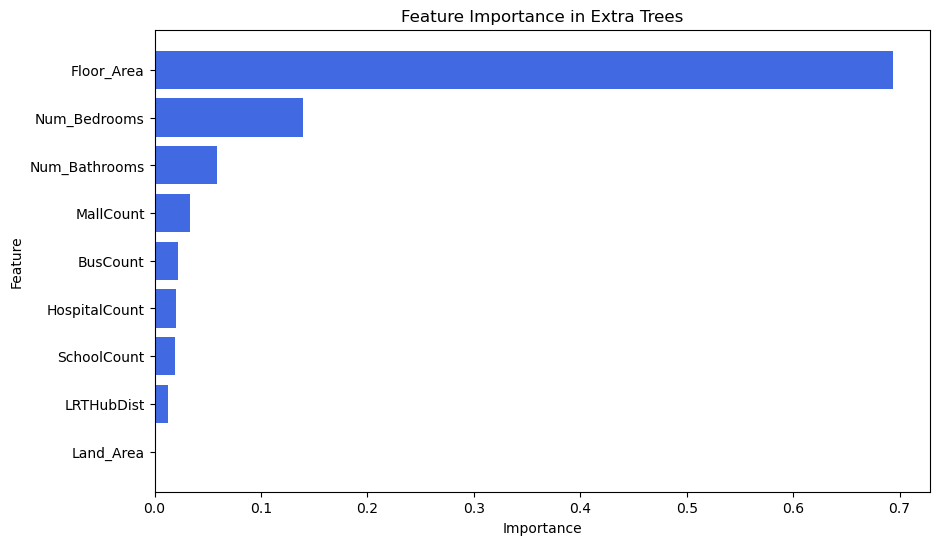

ExtraTreesRegressor(max_depth=14, max_features=8, min_samples_leaf=3,
                    min_samples_split=7, n_estimators=130)

In [55]:
# Assuming df is already loaded and preprocessed
y = apt_df['Price']
X = apt_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusCount', 'SchoolCount', 'MallCount', 'HospitalCount']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)

[I 2025-02-02 19:27:30,384] A new study created in memory with name: no-name-2c9593d7-231f-41e2-af37-600d14abe94e
[I 2025-02-02 19:27:31,494] Trial 0 finished with value: 0.39418552877966717 and parameters: {'n_estimators': 190, 'max_depth': 6, 'max_features': 6, 'min_samples_leaf': 2, 'min_samples_split': 2}. Best is trial 0 with value: 0.39418552877966717.
[I 2025-02-02 19:27:32,496] Trial 1 finished with value: 0.3562631948726083 and parameters: {'n_estimators': 120, 'max_depth': 15, 'max_features': 6, 'min_samples_leaf': 10, 'min_samples_split': 8}. Best is trial 0 with value: 0.39418552877966717.
[I 2025-02-02 19:27:32,940] Trial 2 finished with value: 0.31837148595905246 and parameters: {'n_estimators': 60, 'max_depth': 17, 'max_features': 5, 'min_samples_leaf': 10, 'min_samples_split': 4}. Best is trial 0 with value: 0.39418552877966717.
[I 2025-02-02 19:27:34,305] Trial 3 finished with value: 0.43457525719308565 and parameters: {'n_estimators': 140, 'max_depth': 12, 'max_featur

Best trial:
  Value: 0.46676832624802334
  Params: 
    n_estimators: 120
    max_depth: 15
    max_features: 8
    min_samples_leaf: 3
    min_samples_split: 5

Top Features:
         Feature  Importance
3     Floor_Area    0.656083
4      Land_Area    0.111128
5       BusCount    0.072079
7      MallCount    0.057313
6    SchoolCount    0.048711
0     LRTHubDist    0.027667
8  HospitalCount    0.027019
1   Num_Bedrooms    0.000000
2  Num_Bathrooms    0.000000


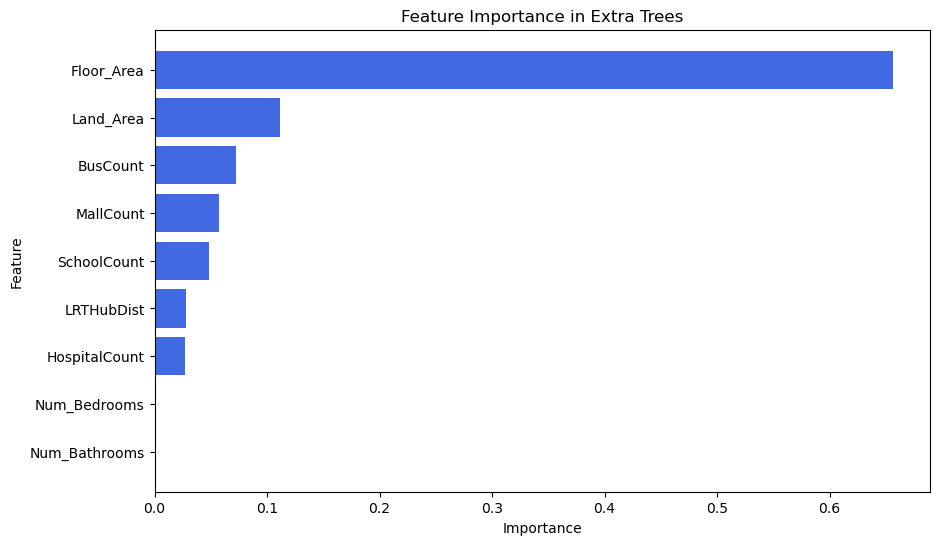

ExtraTreesRegressor(max_depth=15, max_features=8, min_samples_leaf=3,
                    min_samples_split=5, n_estimators=120)

In [57]:
# Assuming df is already loaded and preprocessed
y = com_df['Price']
X = com_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusCount', 'SchoolCount', 'MallCount', 'HospitalCount']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)

[I 2025-02-02 19:30:10,140] A new study created in memory with name: no-name-58832c1b-1c4c-4def-83b6-005c775522a3
[I 2025-02-02 19:30:12,395] Trial 0 finished with value: -0.4437768304815812 and parameters: {'n_estimators': 140, 'max_depth': 14, 'max_features': 7, 'min_samples_leaf': 7, 'min_samples_split': 7}. Best is trial 0 with value: -0.4437768304815812.
[I 2025-02-02 19:30:13,826] Trial 1 finished with value: -0.15845614564497718 and parameters: {'n_estimators': 140, 'max_depth': 20, 'max_features': 4, 'min_samples_leaf': 9, 'min_samples_split': 5}. Best is trial 1 with value: -0.15845614564497718.
[I 2025-02-02 19:30:16,732] Trial 2 finished with value: -0.5515588930647133 and parameters: {'n_estimators': 120, 'max_depth': 20, 'max_features': 8, 'min_samples_leaf': 3, 'min_samples_split': 7}. Best is trial 1 with value: -0.15845614564497718.
[I 2025-02-02 19:30:17,586] Trial 3 finished with value: -0.07642492874569044 and parameters: {'n_estimators': 110, 'max_depth': 11, 'max_f

Best trial:
  Value: 0.007688477460966525
  Params: 
    n_estimators: 140
    max_depth: 7
    max_features: 3
    min_samples_leaf: 3
    min_samples_split: 4

Top Features:
         Feature  Importance
4      Land_Area    0.406498
6    SchoolCount    0.150413
7      MallCount    0.135513
0     LRTHubDist    0.135197
5       BusCount    0.124992
8  HospitalCount    0.047212
3     Floor_Area    0.000176
1   Num_Bedrooms    0.000000
2  Num_Bathrooms    0.000000


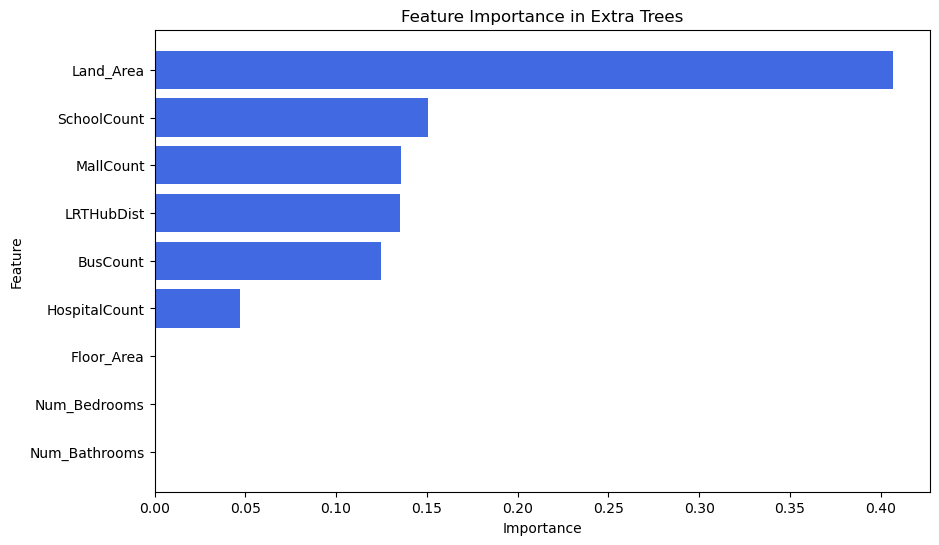

ExtraTreesRegressor(max_depth=7, max_features=3, min_samples_leaf=3,
                    min_samples_split=4, n_estimators=140)

In [59]:
# Assuming df is already loaded and preprocessed
y = land_df['Price']
X = land_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusCount', 'SchoolCount', 'MallCount', 'HospitalCount']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)

[I 2025-02-02 19:33:50,180] A new study created in memory with name: no-name-4534ada3-f14e-49b2-912e-1c5cdb0a73a2
[I 2025-02-02 19:33:52,599] Trial 0 finished with value: 0.23233250141895462 and parameters: {'n_estimators': 60, 'max_depth': 5, 'max_features': 6, 'min_samples_leaf': 8, 'min_samples_split': 3}. Best is trial 0 with value: 0.23233250141895462.
[I 2025-02-02 19:33:57,953] Trial 1 finished with value: 0.14785916810967265 and parameters: {'n_estimators': 200, 'max_depth': 12, 'max_features': 2, 'min_samples_leaf': 8, 'min_samples_split': 4}. Best is trial 0 with value: 0.23233250141895462.
[I 2025-02-02 19:34:02,797] Trial 2 finished with value: 0.1934685556960896 and parameters: {'n_estimators': 170, 'max_depth': 4, 'max_features': 5, 'min_samples_leaf': 5, 'min_samples_split': 6}. Best is trial 0 with value: 0.23233250141895462.
[I 2025-02-02 19:34:05,282] Trial 3 finished with value: 0.16513962035224533 and parameters: {'n_estimators': 90, 'max_depth': 13, 'max_features':

Best trial:
  Value: 0.34899774227703695
  Params: 
    n_estimators: 140
    max_depth: 15
    max_features: 8
    min_samples_leaf: 3
    min_samples_split: 4

Top Features:
         Feature  Importance
4      Land_Area    0.488184
6    SchoolCount    0.117442
3     Floor_Area    0.113199
0     LRTHubDist    0.091266
1   Num_Bedrooms    0.052845
7      MallCount    0.045591
5       BusCount    0.039804
2  Num_Bathrooms    0.028197
8  HospitalCount    0.023472


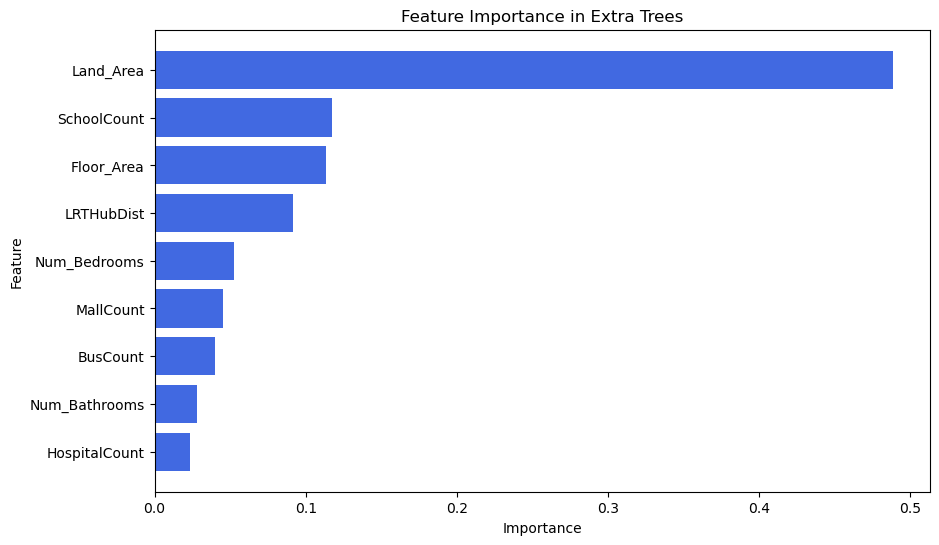

ExtraTreesRegressor(max_depth=15, max_features=8, min_samples_leaf=3,
                    min_samples_split=4, n_estimators=140)

In [61]:
# Assuming df is already loaded and preprocessed
y = RR_df['Price']
X = RR_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusCount', 'SchoolCount', 'MallCount', 'HospitalCount']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)

[I 2025-02-02 20:22:17,195] A new study created in memory with name: no-name-423d7f94-b2a2-409f-9223-0b9a61a36116
[I 2025-02-02 20:22:22,943] Trial 0 finished with value: -0.46190619036144404 and parameters: {'n_estimators': 80, 'max_depth': 15, 'max_features': 7, 'min_samples_leaf': 5, 'min_samples_split': 9}. Best is trial 0 with value: -0.46190619036144404.
[I 2025-02-02 20:22:25,196] Trial 1 finished with value: -0.4816331766204242 and parameters: {'n_estimators': 30, 'max_depth': 13, 'max_features': 7, 'min_samples_leaf': 3, 'min_samples_split': 2}. Best is trial 0 with value: -0.46190619036144404.
[I 2025-02-02 20:22:39,384] Trial 2 finished with value: -0.5063010617051871 and parameters: {'n_estimators': 170, 'max_depth': 14, 'max_features': 8, 'min_samples_leaf': 4, 'min_samples_split': 5}. Best is trial 0 with value: -0.46190619036144404.
[I 2025-02-02 20:22:41,725] Trial 3 finished with value: -0.011351605658448505 and parameters: {'n_estimators': 80, 'max_depth': 5, 'max_fea

Best trial:
  Value: 0.07827707052626423
  Params: 
    n_estimators: 110
    max_depth: 3
    max_features: 9
    min_samples_leaf: 2
    min_samples_split: 7

Top Features:
         Feature  Importance
4      Land_Area    0.493583
3     Floor_Area    0.255453
6    SchoolCount    0.078779
0     LRTHubDist    0.064255
7      MallCount    0.054130
5       BusCount    0.045653
8  HospitalCount    0.008148
1   Num_Bedrooms    0.000000
2  Num_Bathrooms    0.000000


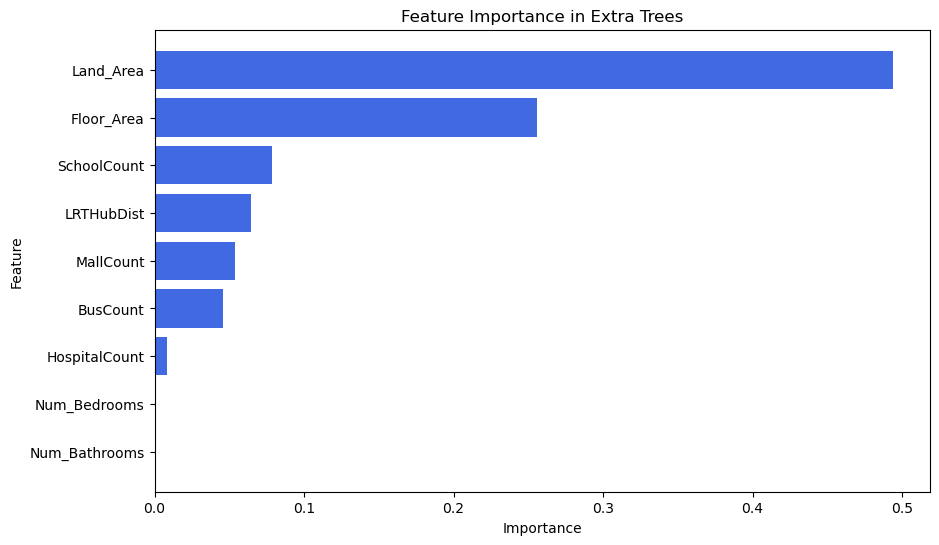

ExtraTreesRegressor(max_depth=3, max_features=9, min_samples_leaf=2,
                    min_samples_split=7, n_estimators=110)

In [63]:
# Assuming df is already loaded and preprocessed
y = CR_df['Price']
X = CR_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusCount', 'SchoolCount', 'MallCount', 'HospitalCount']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)

[I 2025-02-02 20:33:25,462] A new study created in memory with name: no-name-dad9ed78-9975-40a9-b5d7-6d32f260586c
[I 2025-02-02 20:33:31,495] Trial 0 finished with value: -1.8773461125754853 and parameters: {'n_estimators': 140, 'max_depth': 3, 'max_features': 5, 'min_samples_leaf': 8, 'min_samples_split': 4}. Best is trial 0 with value: -1.8773461125754853.
[I 2025-02-02 20:33:38,214] Trial 1 finished with value: -2.246746891242892 and parameters: {'n_estimators': 190, 'max_depth': 2, 'max_features': 6, 'min_samples_leaf': 5, 'min_samples_split': 8}. Best is trial 0 with value: -1.8773461125754853.
[I 2025-02-02 20:34:32,267] Trial 2 finished with value: -1.6909180673618949 and parameters: {'n_estimators': 140, 'max_depth': 17, 'max_features': 9, 'min_samples_leaf': 2, 'min_samples_split': 2}. Best is trial 2 with value: -1.6909180673618949.
[I 2025-02-02 20:34:34,442] Trial 3 finished with value: -2.8649750895695676 and parameters: {'n_estimators': 80, 'max_depth': 3, 'max_features':

Best trial:
  Value: 0.1796934672972021
  Params: 
    n_estimators: 200
    max_depth: 11
    max_features: 7
    min_samples_leaf: 4
    min_samples_split: 7

Top Features:
           Feature  Importance
4        Land_Area    0.434777
6    SchoolHubDist    0.178760
3       Floor_Area    0.099658
0       LRTHubDist    0.097725
8  HospitalHubDist    0.062722
7      MallHubDist    0.057534
5       BusHubDist    0.038229
2    Num_Bathrooms    0.015423
1     Num_Bedrooms    0.015171


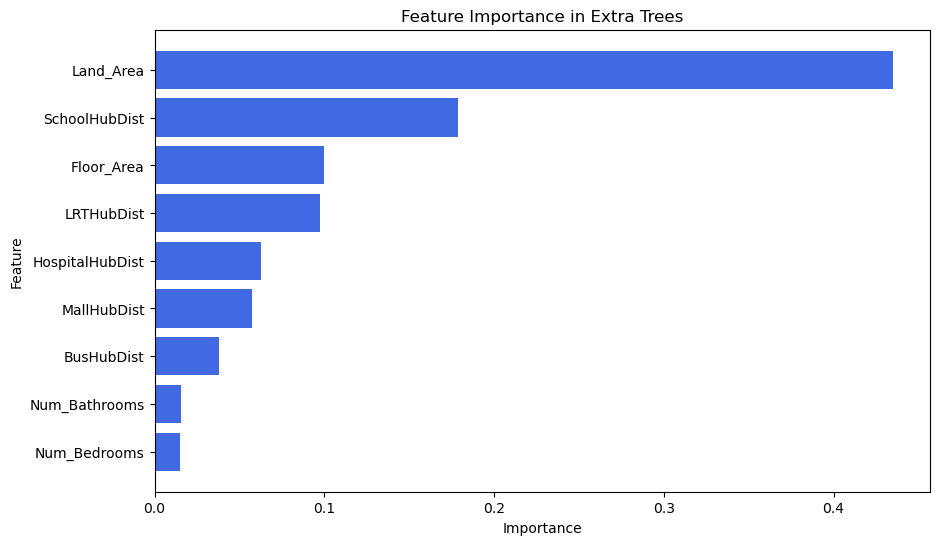

ExtraTreesRegressor(max_depth=11, max_features=7, min_samples_leaf=4,
                    min_samples_split=7, n_estimators=200)

In [67]:
# Assuming df is already loaded and preprocessed
y = house_df['Price']
X = house_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusHubDist', 'SchoolHubDist', 'MallHubDist', 'HospitalHubDist']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)

[I 2025-02-02 21:16:43,984] A new study created in memory with name: no-name-bbca2a1a-3e13-48c5-8252-f2083cde2e3d
[I 2025-02-02 21:16:47,230] Trial 0 finished with value: 0.35715023080811004 and parameters: {'n_estimators': 30, 'max_depth': 11, 'max_features': 7, 'min_samples_leaf': 3, 'min_samples_split': 9}. Best is trial 0 with value: 0.35715023080811004.
[I 2025-02-02 21:17:12,700] Trial 1 finished with value: 0.39090632329613373 and parameters: {'n_estimators': 110, 'max_depth': 16, 'max_features': 9, 'min_samples_leaf': 4, 'min_samples_split': 10}. Best is trial 1 with value: 0.39090632329613373.
[I 2025-02-02 21:17:20,790] Trial 2 finished with value: 0.08629347166493298 and parameters: {'n_estimators': 140, 'max_depth': 5, 'max_features': 6, 'min_samples_leaf': 9, 'min_samples_split': 5}. Best is trial 1 with value: 0.39090632329613373.
[I 2025-02-02 21:17:46,510] Trial 3 finished with value: 0.3328231615863538 and parameters: {'n_estimators': 180, 'max_depth': 12, 'max_feature

Best trial:
  Value: 0.40822172070920326
  Params: 
    n_estimators: 140
    max_depth: 18
    max_features: 9
    min_samples_leaf: 2
    min_samples_split: 6

Top Features:
           Feature  Importance
3       Floor_Area    0.543726
1     Num_Bedrooms    0.132545
2    Num_Bathrooms    0.094792
0       LRTHubDist    0.050883
8  HospitalHubDist    0.049945
5       BusHubDist    0.043858
7      MallHubDist    0.042128
6    SchoolHubDist    0.042124
4        Land_Area    0.000000


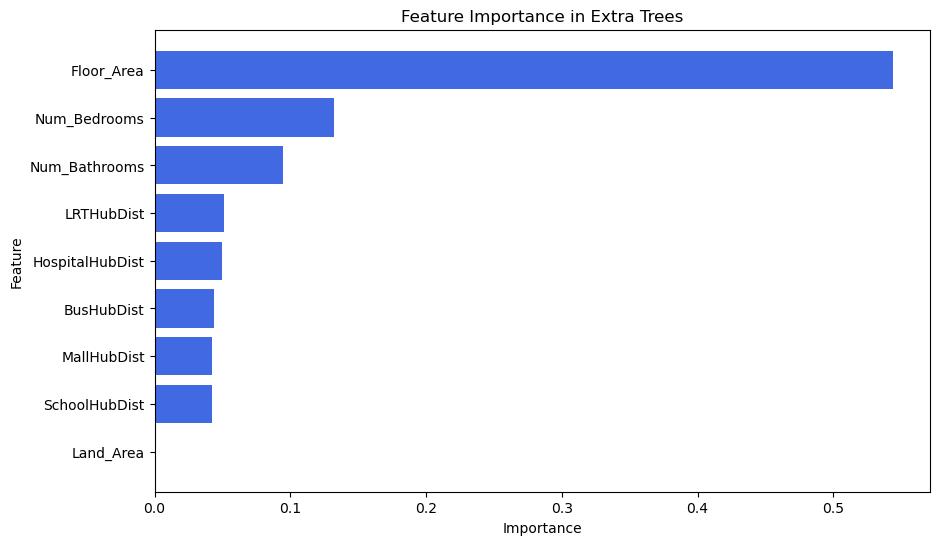

ExtraTreesRegressor(max_depth=18, max_features=9, min_samples_leaf=2,
                    min_samples_split=6, n_estimators=140)

In [69]:
# Assuming df is already loaded and preprocessed
y = condo_df['Price']
X = condo_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusHubDist', 'SchoolHubDist', 'MallHubDist', 'HospitalHubDist']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)

[I 2025-02-02 22:12:12,193] A new study created in memory with name: no-name-a0ec8ff5-7519-4cfa-bc74-886cf1031bbe
[I 2025-02-02 22:12:13,603] Trial 0 finished with value: 0.46264601357033436 and parameters: {'n_estimators': 120, 'max_depth': 9, 'max_features': 5, 'min_samples_leaf': 4, 'min_samples_split': 9}. Best is trial 0 with value: 0.46264601357033436.
[I 2025-02-02 22:12:15,060] Trial 1 finished with value: 0.39943300001017845 and parameters: {'n_estimators': 140, 'max_depth': 8, 'max_features': 5, 'min_samples_leaf': 7, 'min_samples_split': 3}. Best is trial 0 with value: 0.46264601357033436.
[I 2025-02-02 22:12:16,485] Trial 2 finished with value: 0.44193700918258705 and parameters: {'n_estimators': 160, 'max_depth': 4, 'max_features': 8, 'min_samples_leaf': 2, 'min_samples_split': 8}. Best is trial 0 with value: 0.46264601357033436.
[I 2025-02-02 22:12:18,760] Trial 3 finished with value: 0.3877041185385523 and parameters: {'n_estimators': 200, 'max_depth': 7, 'max_features':

Best trial:
  Value: 0.520245264860853
  Params: 
    n_estimators: 100
    max_depth: 13
    max_features: 5
    min_samples_leaf: 2
    min_samples_split: 3

Top Features:
           Feature  Importance
3       Floor_Area    0.493924
1     Num_Bedrooms    0.194964
8  HospitalHubDist    0.086602
2    Num_Bathrooms    0.085651
6    SchoolHubDist    0.045861
7      MallHubDist    0.042968
5       BusHubDist    0.029519
0       LRTHubDist    0.020511
4        Land_Area    0.000000


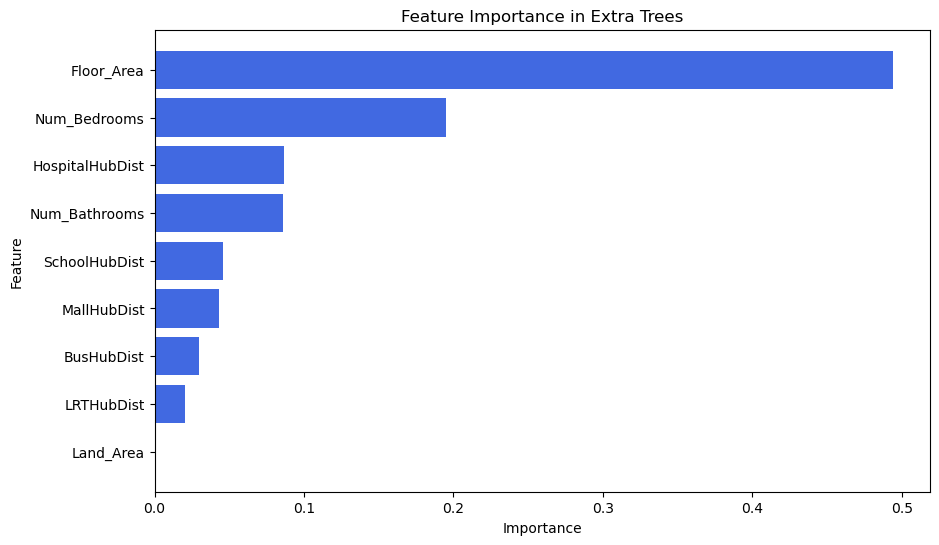

ExtraTreesRegressor(max_depth=13, max_features=5, min_samples_leaf=2,
                    min_samples_split=3)

In [71]:
# Assuming df is already loaded and preprocessed
y = apt_df['Price']
X = apt_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusHubDist', 'SchoolHubDist', 'MallHubDist', 'HospitalHubDist']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)

[I 2025-02-02 22:16:27,900] A new study created in memory with name: no-name-ad4e34e8-2193-4322-b09e-0406f6a63f7d
[I 2025-02-02 22:16:29,397] Trial 0 finished with value: 0.24451947687266093 and parameters: {'n_estimators': 110, 'max_depth': 4, 'max_features': 4, 'min_samples_leaf': 6, 'min_samples_split': 3}. Best is trial 0 with value: 0.24451947687266093.
[I 2025-02-02 22:16:33,461] Trial 1 finished with value: 0.4065879315556124 and parameters: {'n_estimators': 150, 'max_depth': 12, 'max_features': 7, 'min_samples_leaf': 6, 'min_samples_split': 5}. Best is trial 1 with value: 0.4065879315556124.
[I 2025-02-02 22:16:36,663] Trial 2 finished with value: 0.3889873366166616 and parameters: {'n_estimators': 140, 'max_depth': 15, 'max_features': 4, 'min_samples_leaf': 5, 'min_samples_split': 4}. Best is trial 1 with value: 0.4065879315556124.
[I 2025-02-02 22:16:37,336] Trial 3 finished with value: 0.39335424119906215 and parameters: {'n_estimators': 30, 'max_depth': 8, 'max_features': 6

Best trial:
  Value: 0.45139747788022955
  Params: 
    n_estimators: 120
    max_depth: 14
    max_features: 6
    min_samples_leaf: 3
    min_samples_split: 4

Top Features:
           Feature  Importance
3       Floor_Area    0.695999
4        Land_Area    0.109927
6    SchoolHubDist    0.049828
7      MallHubDist    0.041545
0       LRTHubDist    0.035216
8  HospitalHubDist    0.034477
5       BusHubDist    0.033007
1     Num_Bedrooms    0.000000
2    Num_Bathrooms    0.000000


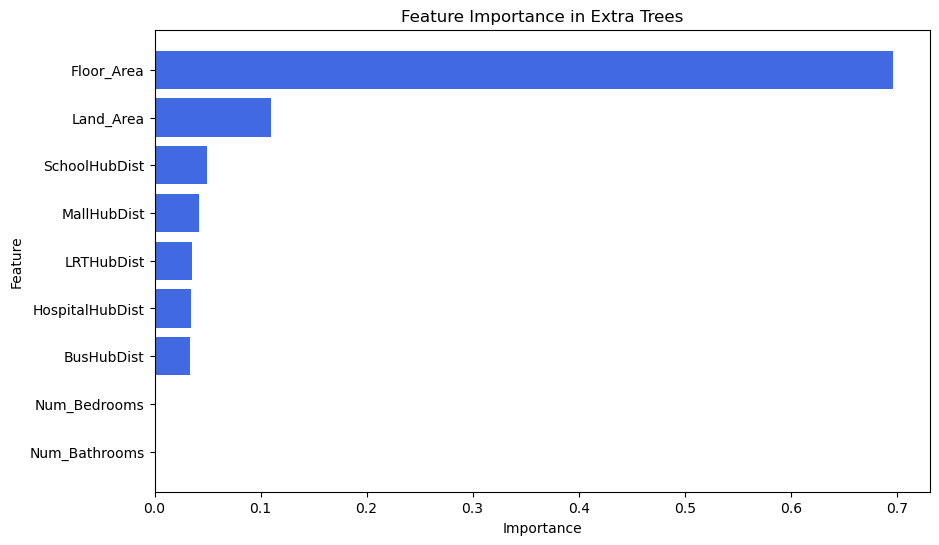

ExtraTreesRegressor(max_depth=14, max_features=6, min_samples_leaf=3,
                    min_samples_split=4, n_estimators=120)

In [73]:
# Assuming df is already loaded and preprocessed
y = com_df['Price']
X = com_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusHubDist', 'SchoolHubDist', 'MallHubDist', 'HospitalHubDist']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)

[I 2025-02-02 22:35:17,939] A new study created in memory with name: no-name-20b9ecbd-693d-4cce-a968-3da7ebc8996b
[I 2025-02-02 22:35:29,902] Trial 0 finished with value: -0.7550786566781904 and parameters: {'n_estimators': 180, 'max_depth': 17, 'max_features': 9, 'min_samples_leaf': 9, 'min_samples_split': 5}. Best is trial 0 with value: -0.7550786566781904.
[I 2025-02-02 22:35:30,227] Trial 1 finished with value: -0.8058847618320255 and parameters: {'n_estimators': 10, 'max_depth': 7, 'max_features': 4, 'min_samples_leaf': 5, 'min_samples_split': 4}. Best is trial 0 with value: -0.7550786566781904.
[I 2025-02-02 22:35:30,644] Trial 2 finished with value: -0.5292926654602738 and parameters: {'n_estimators': 20, 'max_depth': 2, 'max_features': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}. Best is trial 2 with value: -0.5292926654602738.
[I 2025-02-02 22:35:32,467] Trial 3 finished with value: -0.1538829606178836 and parameters: {'n_estimators': 110, 'max_depth': 20, 'max_features

Best trial:
  Value: -0.10366418627524161
  Params: 
    n_estimators: 10
    max_depth: 19
    max_features: 2
    min_samples_leaf: 9
    min_samples_split: 3

Top Features:
           Feature  Importance
7      MallHubDist    0.341280
5       BusHubDist    0.224404
0       LRTHubDist    0.164951
6    SchoolHubDist    0.161205
8  HospitalHubDist    0.082469
4        Land_Area    0.025691
1     Num_Bedrooms    0.000000
2    Num_Bathrooms    0.000000
3       Floor_Area    0.000000


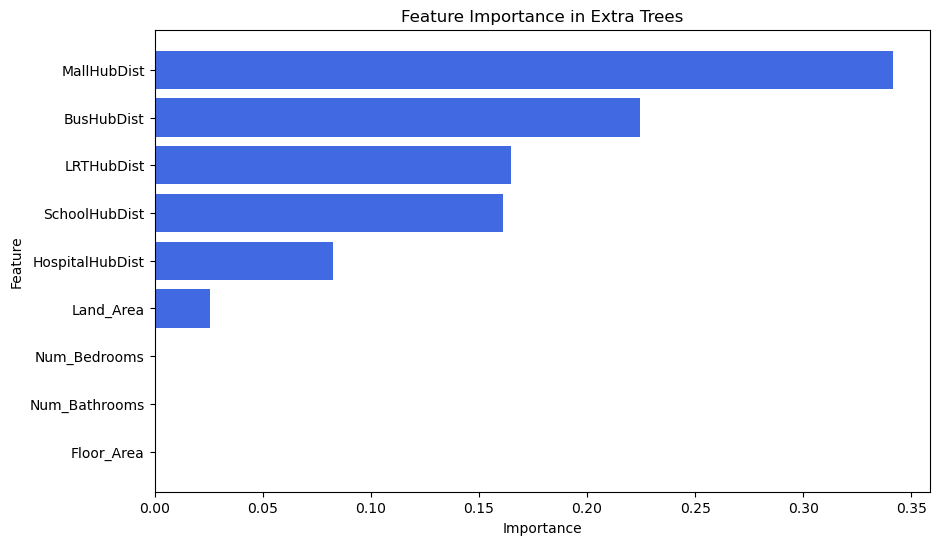

ExtraTreesRegressor(max_depth=19, max_features=2, min_samples_leaf=9,
                    min_samples_split=3, n_estimators=10)

In [75]:
# Assuming df is already loaded and preprocessed
y = land_df['Price']
X = land_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusHubDist', 'SchoolHubDist', 'MallHubDist', 'HospitalHubDist']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)

[I 2025-02-02 22:38:57,007] A new study created in memory with name: no-name-f70954d9-9210-4863-bbf1-ee94d1b91150
[I 2025-02-02 22:39:03,666] Trial 0 finished with value: 0.28711295392418823 and parameters: {'n_estimators': 110, 'max_depth': 7, 'max_features': 7, 'min_samples_leaf': 9, 'min_samples_split': 2}. Best is trial 0 with value: 0.28711295392418823.
[I 2025-02-02 22:39:18,693] Trial 1 finished with value: 0.3389937159655802 and parameters: {'n_estimators': 130, 'max_depth': 17, 'max_features': 5, 'min_samples_leaf': 7, 'min_samples_split': 7}. Best is trial 1 with value: 0.3389937159655802.
[I 2025-02-02 22:39:36,542] Trial 2 finished with value: 0.3298937971959926 and parameters: {'n_estimators': 170, 'max_depth': 11, 'max_features': 8, 'min_samples_leaf': 5, 'min_samples_split': 2}. Best is trial 1 with value: 0.3389937159655802.
[I 2025-02-02 22:39:41,698] Trial 3 finished with value: 0.3106846226655516 and parameters: {'n_estimators': 70, 'max_depth': 13, 'max_features': 4

Best trial:
  Value: 0.35313963695981376
  Params: 
    n_estimators: 140
    max_depth: 17
    max_features: 5
    min_samples_leaf: 4
    min_samples_split: 6

Top Features:
           Feature  Importance
4        Land_Area    0.434954
6    SchoolHubDist    0.129908
3       Floor_Area    0.128204
0       LRTHubDist    0.079032
8  HospitalHubDist    0.074981
7      MallHubDist    0.045567
5       BusHubDist    0.043839
1     Num_Bedrooms    0.034549
2    Num_Bathrooms    0.028965


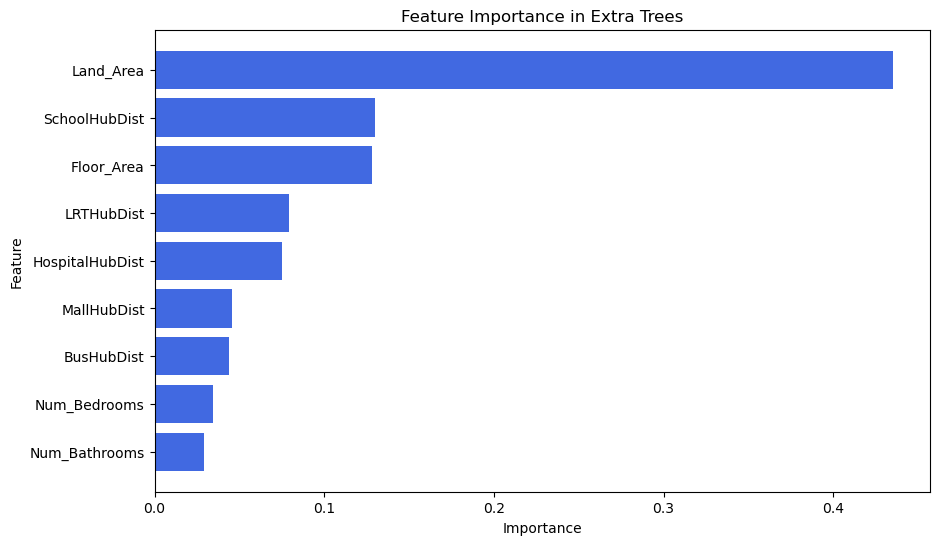

ExtraTreesRegressor(max_depth=17, max_features=5, min_samples_leaf=4,
                    min_samples_split=6, n_estimators=140)

In [77]:
# Assuming df is already loaded and preprocessed
y = RR_df['Price']
X = RR_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusHubDist', 'SchoolHubDist', 'MallHubDist', 'HospitalHubDist']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)

[I 2025-02-02 23:09:42,065] A new study created in memory with name: no-name-33aa9fe8-ddb7-4488-b0ee-851e6759a6aa
[I 2025-02-02 23:09:46,040] Trial 0 finished with value: -0.8975064259587787 and parameters: {'n_estimators': 180, 'max_depth': 14, 'max_features': 6, 'min_samples_leaf': 3, 'min_samples_split': 9}. Best is trial 0 with value: -0.8975064259587787.
[I 2025-02-02 23:09:46,722] Trial 1 finished with value: -0.15769778665909023 and parameters: {'n_estimators': 100, 'max_depth': 2, 'max_features': 9, 'min_samples_leaf': 7, 'min_samples_split': 9}. Best is trial 1 with value: -0.15769778665909023.
[I 2025-02-02 23:09:51,116] Trial 2 finished with value: -1.3531791217235885 and parameters: {'n_estimators': 150, 'max_depth': 20, 'max_features': 6, 'min_samples_leaf': 4, 'min_samples_split': 3}. Best is trial 1 with value: -0.15769778665909023.
[I 2025-02-02 23:09:53,138] Trial 3 finished with value: -0.4498492690410448 and parameters: {'n_estimators': 80, 'max_depth': 13, 'max_feat

Best trial:
  Value: 0.007274042639525247
  Params: 
    n_estimators: 10
    max_depth: 10
    max_features: 2
    min_samples_leaf: 6
    min_samples_split: 4

Top Features:
           Feature  Importance
5       BusHubDist    0.457862
0       LRTHubDist    0.325961
8  HospitalHubDist    0.092173
7      MallHubDist    0.039375
6    SchoolHubDist    0.032542
3       Floor_Area    0.030420
4        Land_Area    0.021667
1     Num_Bedrooms    0.000000
2    Num_Bathrooms    0.000000


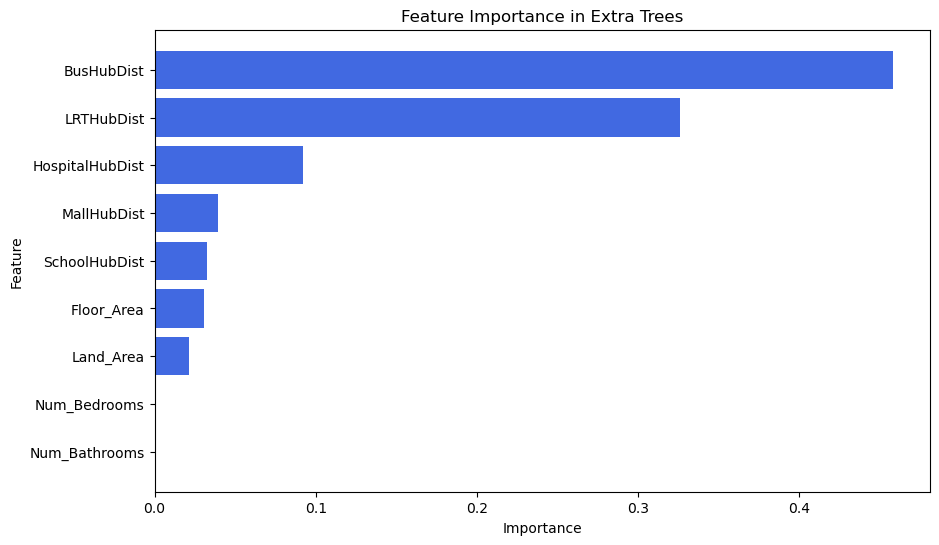

ExtraTreesRegressor(max_depth=10, max_features=2, min_samples_leaf=6,
                    min_samples_split=4, n_estimators=10)

In [79]:
# Assuming df is already loaded and preprocessed
y = CR_df['Price']
X = CR_df[["LRTHubDist", 'Num_Bedrooms', 'Num_Bathrooms', 'Floor_Area', 'Land_Area', 
        'BusHubDist', 'SchoolHubDist', 'MallHubDist', 'HospitalHubDist']]

# Optimize and get best parameters
best_params = optimize_extra_trees(X, y)
feature_importances = get_feature_importance(X, y, best_params)

# Train final model with best parameters
final_model = ExtraTreesRegressor(**best_params, criterion='squared_error', bootstrap=False)
final_model.fit(X, y)